In [4]:
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

In [19]:
def coupling_matrix_of_N(N):                                              #coupling_matrix_of_N
    location = np.linspace(x_0, x_1, N)
    di=np.zeros((N),dtype=complex)
    for i in np.arange(N):
        di[i]=constant_1*(-1)**(i) 
    matrix_collect = np.zeros((N, 2, 2), dtype=complex)
    for i in np.arange(N):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(N))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
  #  print(matrix_6)
 #   print(di)
    return matrix_6
def Transmission_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[1][0]**2))
def Reflection_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[0][0]**2))

In [17]:
y=1j
m=0.5#complex(9.1093837*10**(-31))                                       #constant
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-1#(-1*10**(-15))
x_1=1#(1*10**(-15))                                             
constant_1=2*m*y/(h1**2)
Transmission_coefficient_of_N(1)

[[-0.41614684-0.90929743j  0.        +0.j        ]
 [ 2.        +0.j          0.        +0.j        ]]


4.0

In [7]:
y=0.6
m=0.5#complex(9.1093837*10**(-31))                                       #constant
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))                                             
constant_1=2*m*y/(h1**2)
a11=Transmission_coefficient_of_N(10000)
print(Transmission_coefficient_of_N(10)+Reflection_coefficient_of_N(10))

0.9999999999999984


In [8]:
y=1j
m=0.5#complex(9.1093837*10**(-31))                                       #constant
h=2*np.pi#6.62607015*10**(-34)
h1=complex(h/(2*np.pi))
E=complex(1)
k=(2*m*E/(h1**2))**0.5
x_0=-0.5#(-1*10**(-15))
x_1=0.5#(1*10**(-15))                                             
constant_1=2*m*y/(h1**2)
a12=Transmission_coefficient_of_N(10000)
print(Transmission_coefficient_of_N(10000),Reflection_coefficient_of_N(10000))

1.169715057055612 0.509145171168291


In [9]:
print(a11+a12)

2.1066930874096945


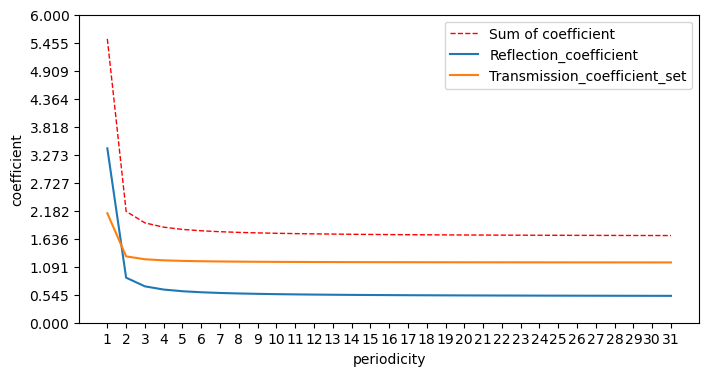

1.7198944296508247


In [10]:
import matplotlib.pyplot as plt       #draw a diagram (The change of transmission coefficient and reflection coefficient with period number n)
def draw_a_diagram_1(n2):
    n1=1
    Reflection_coefficient_set=np.zeros((n2),dtype=float)
    for i in np.arange(n1,n2+1):
        Reflection_coefficient_set[i-1]= Reflection_coefficient_of_N(2*i)
    Transmission_coefficient_set=np.zeros((n2),dtype=float)
    for i in np.arange(n1,n2+1):
        Transmission_coefficient_set[i-1]= Transmission_coefficient_of_N(2*i)
    x = np.arange(n1,n2+1,1)
    y1 = Reflection_coefficient_set
    y2 = Transmission_coefficient_set
    plt.figure(num=2, figsize=(8, 4))
    plt.plot(x, y1+y2, color='red', linewidth='1.0', linestyle='--',label='Sum of coefficient')
    plt.plot(x, y1,label='Reflection_coefficient')
    plt.plot(x, y2,label='Transmission_coefficient_set')
    plt.xlabel('periodicity')
    plt.ylabel('coefficient')
    new_ticks1 = np.linspace(1, n2, n2)
    new_ticks2 = np.linspace(0, 6, 12)
    plt.xticks(new_ticks1)
    plt.yticks(new_ticks2)
    plt.legend()
    plt.show()
draw_a_diagram_1(31)
print(Reflection_coefficient_of_N(30)+Transmission_coefficient_of_N(30))

In [31]:
%matplotlib qt
m=0.5                                   
h1=1
x_0=-0.50
x_1=0.50
n=2
k_set=np.linspace(0,10,1000)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 10,11)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\886785167.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\904419380.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\904419380.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\904419380.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\904419380.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


C:\Users\taoji\AppData\Local\Temp\ipykernel_17356\886785167.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)


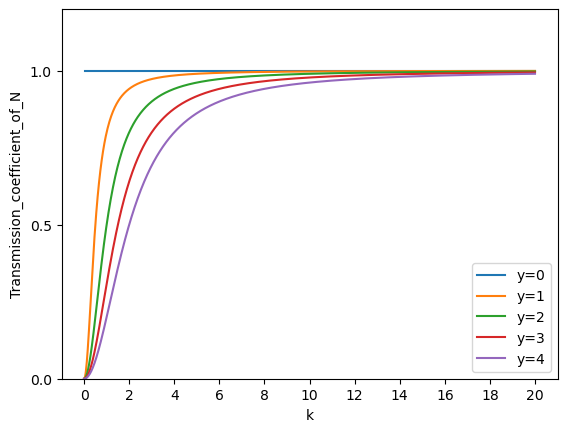

In [23]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5 
n=1
k_set=np.linspace(0,20,1000)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 20,11)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 1.2)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\1403686263.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


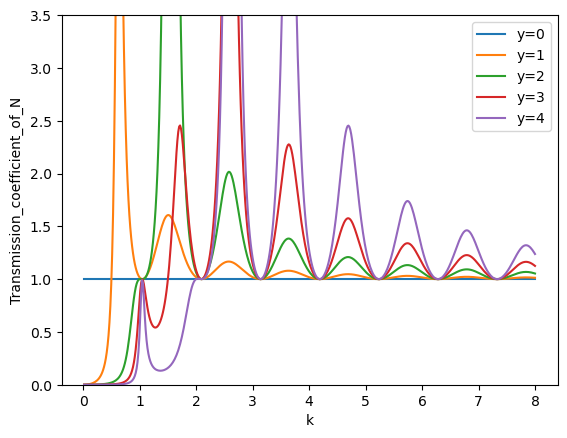

In [12]:
m=0.5                                   
h1=1
x_0=-1.5
x_1=1.5
n=2
k_set=np.linspace(0,8,500)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 8,9)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\1403686263.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)


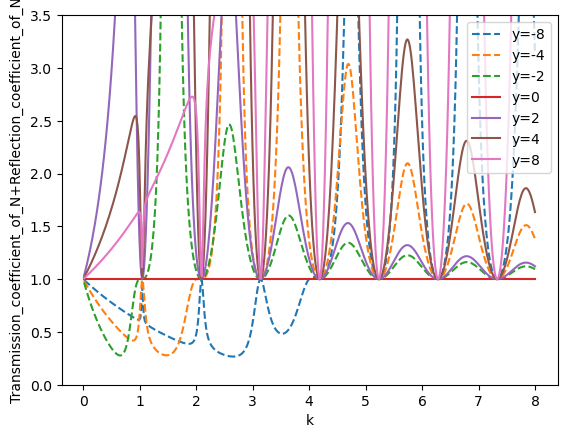

In [13]:
m=0.5                                   
h1=1
x_0=-1.5
x_1=1.5
n=2
k_set=np.linspace(0,8,500)                                        
y_all_set=np.zeros((7,len(k_set)),dtype=float)
for i,l in zip([-8, -4, -2, 0, 2, 4, 8],[0,1,2,3,4,5,6]):
    y=1j*(i)
    constant_1=2*m*y/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)+Reflection_coefficient_of_N(n)
    y_all_set[l]=y_set
for i,l in zip([-8, -4, -2, 0, 2, 4, 8],[0,1,2,3,4,5,6]):
    linestyle = '--' if i < 0 else '-'
    plt.plot(k_set, y_all_set[l], label=f'y={i}', linestyle=linestyle)
new_ticks1 = np.linspace(0, 8,9)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N+Reflection_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\1403686263.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


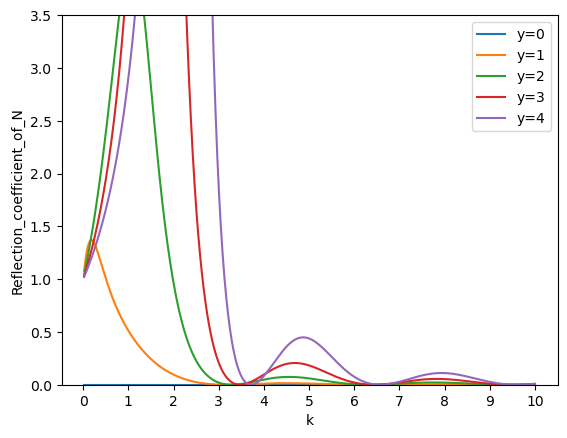

In [14]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5
n=300
k_set=np.linspace(0,10,500)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y=i*1j
    constant_1=2*m*y/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Reflection_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 10,11)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Reflection_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\1403686263.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_10548\904419380.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


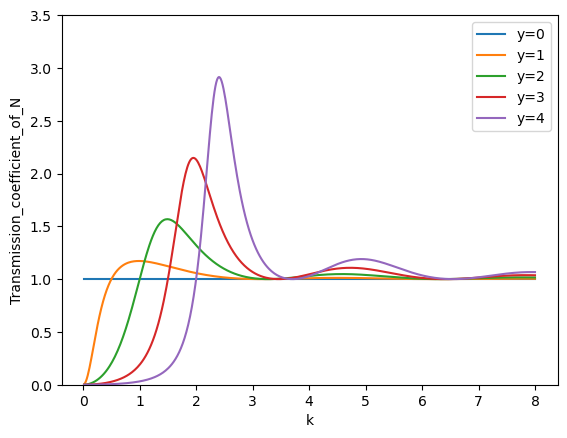

In [16]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5
n=150
k_set=np.linspace(0,8,500)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 8,9)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()